# Silkscan Pipeline Demo

In [1]:
import os, sys, cv2
# Add the root directory to sys.path so we can find the silkscan package 
# if it's not installed in the current environment.
sys.path.append(os.path.abspath('..'))

import silkscan, open3d as o3d, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import uniform_filter1d

# Our compartmentalized logic from the silkscan package
from silkscan import (
    get_brightness_cached, get_sum_image_cached, 
    detect_quad_rotated, SweepProcessor, SweepMerger
)
from notebook_utils import plot_diagnostic_row

%matplotlib inline

## 1. Load Capture Set

In [2]:
capture_set = silkscan.load_capture_set('../scans/tangle016')
print(f'Loaded {capture_set.name} with {len(capture_set.sweeps)} sweeps.')

Loaded tangle016 with 3 sweeps.


## 2. Configure Pipeline

In [3]:
config_steger = silkscan.Config(
    method='steger', intensity_threshold=0.05, strength_threshold=0.002,
    high_intensity_threshold=0.15, high_strength_threshold=0.015,
    sigma=0.5, persistence_min_frames=5, temporal_spatial_radius=2.0,
    spatial_2d_min_length_px=20, temporal_stack_frames=5,
    dedup_radius_mm=0.5, icp_voxel_size=2.0, icp_distance_threshold=5.0,
    box_crop_padding_px=25)
config_thresh = silkscan.Config(
    method='threshold', intensity_threshold=0.15,
    persistence_min_frames=5, temporal_spatial_radius=2.0,
    dedup_radius_mm=0.5, icp_voxel_size=2.0, icp_distance_threshold=5.0,
    box_crop_padding_px=25)

output_dir = '../scans/tangle016'
os.makedirs(output_dir, exist_ok=True)
cache_dir = os.path.join(output_dir, '.cache')
os.makedirs(cache_dir, exist_ok=True)

## 3. Quad Detection & Diagnostics

  Detecting quad for sweep1...
  Detecting quad for sweep2...
  Detecting quad for sweep3...


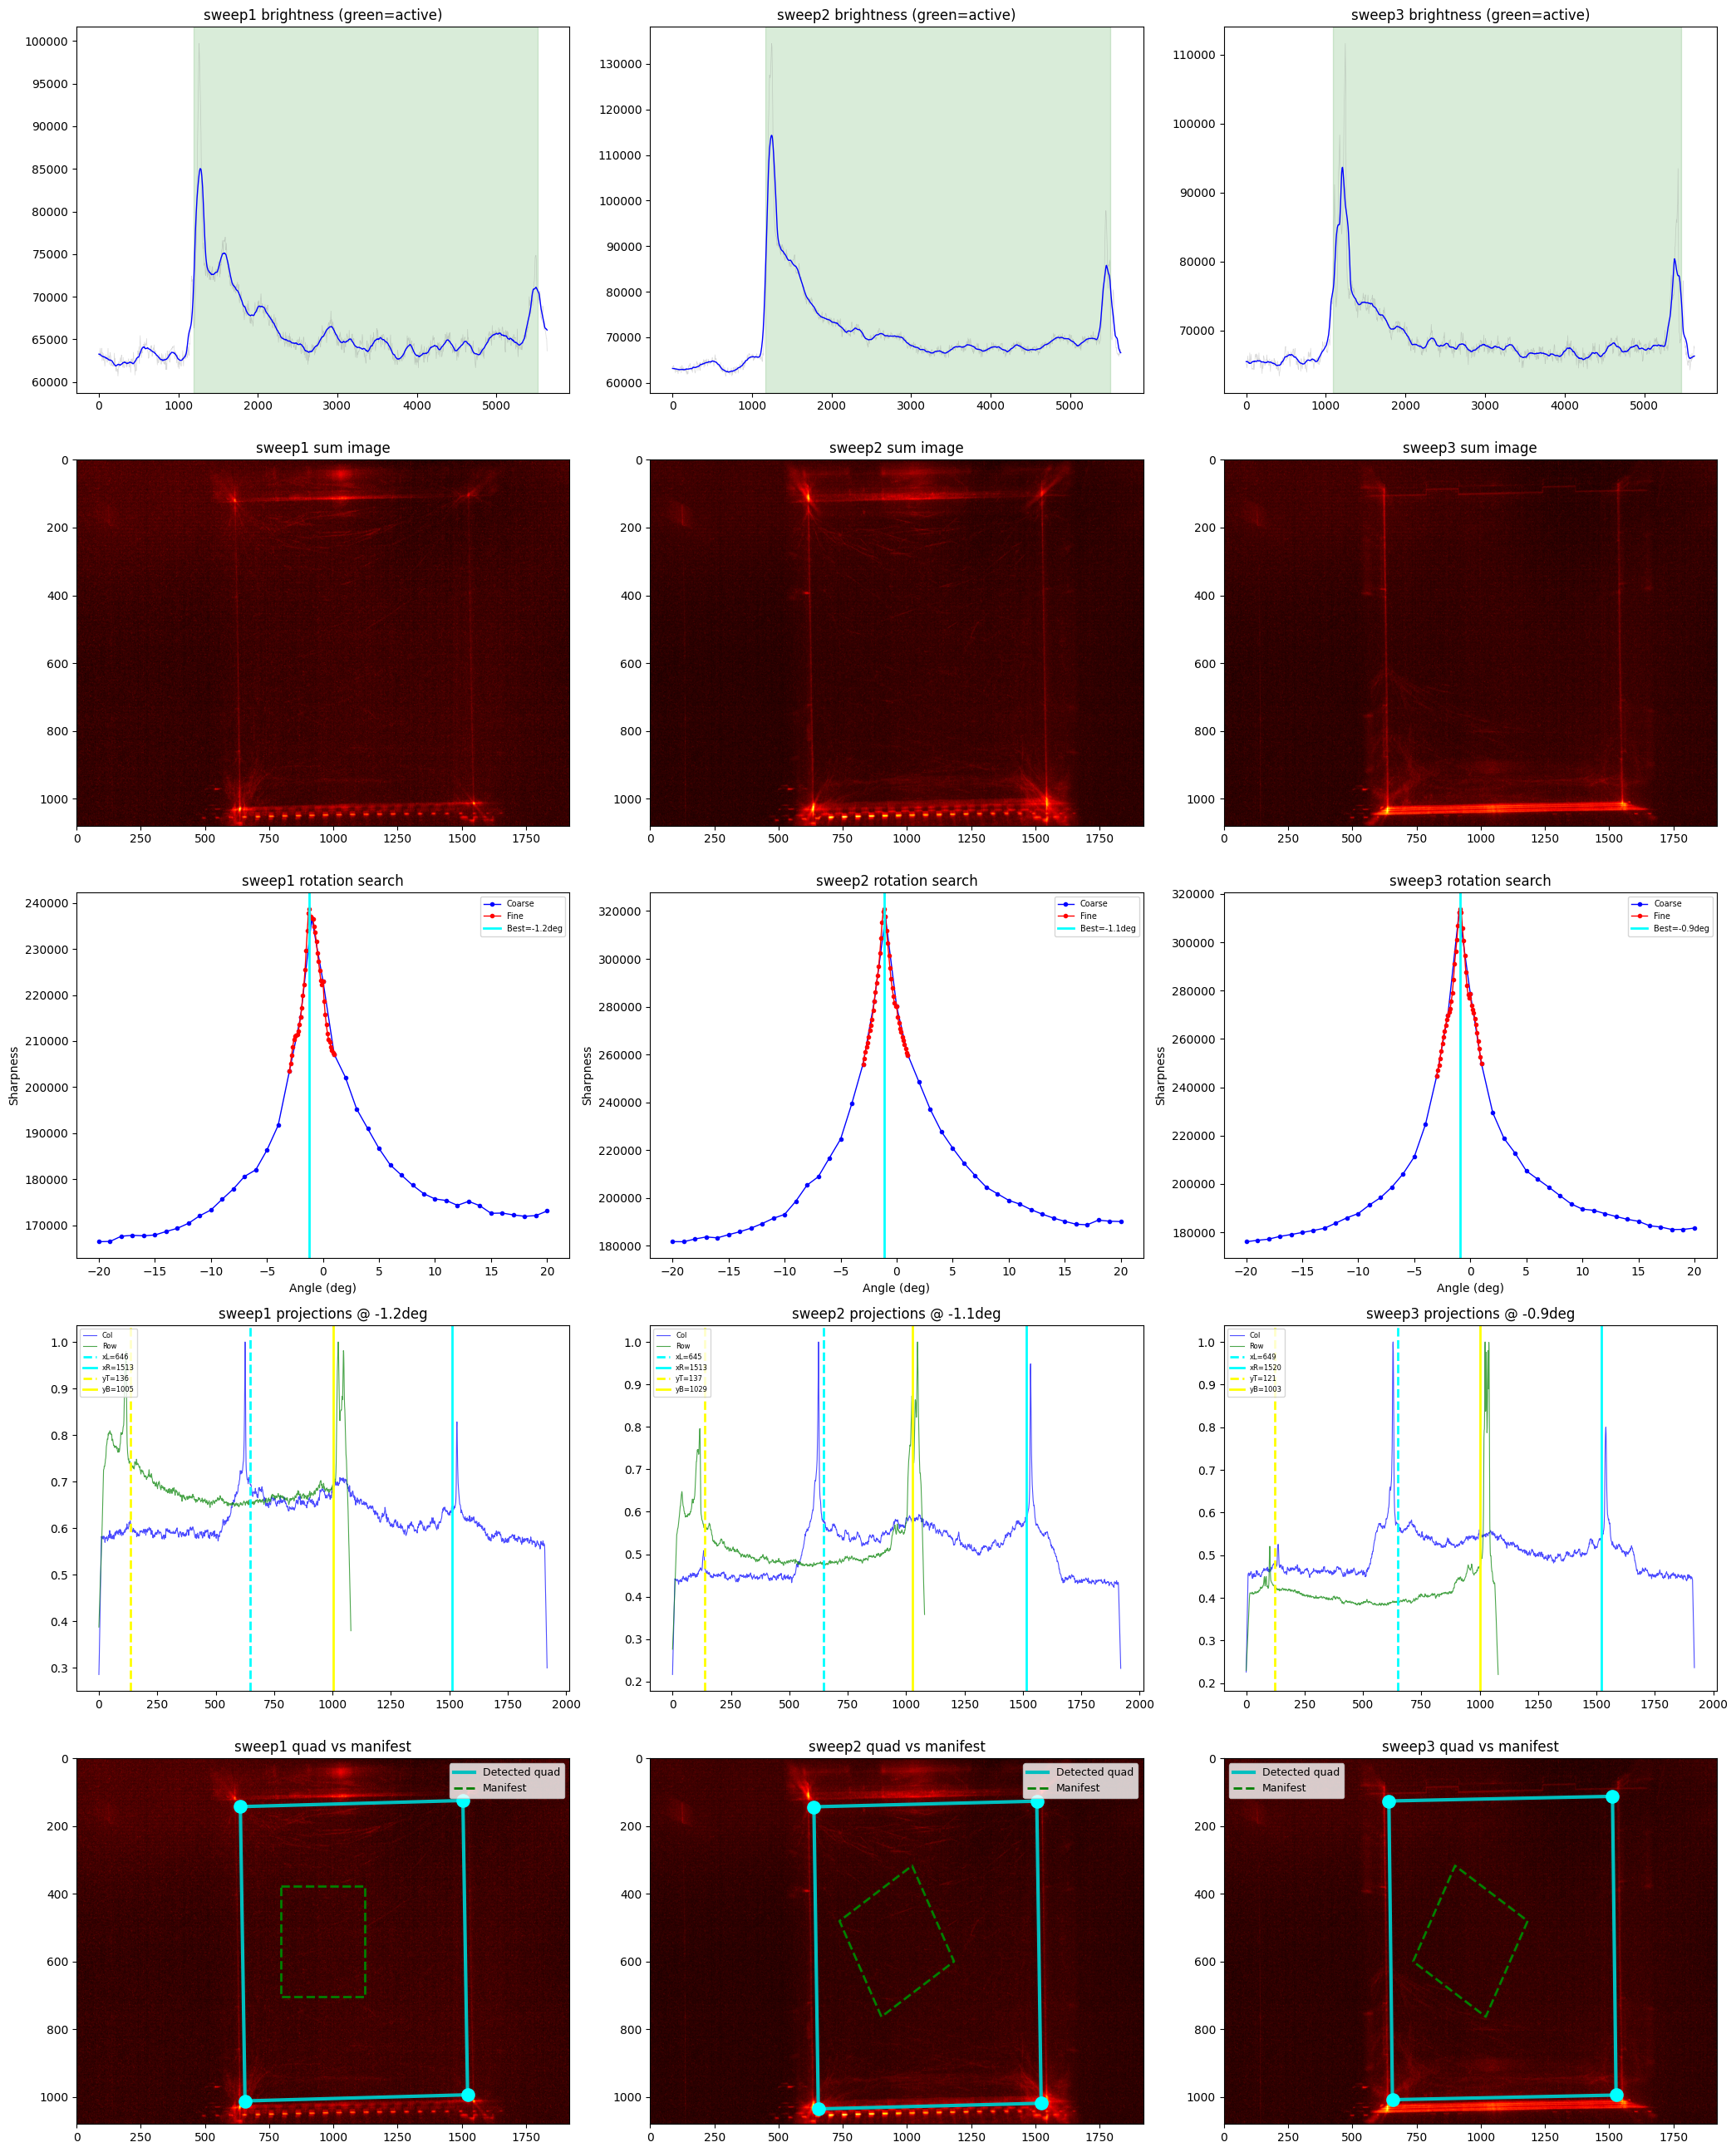

In [4]:
n_sweeps = len(capture_set.sweeps)
fig, axes = plt.subplots(5, n_sweeps, figsize=(7*n_sweeps, 26))
if n_sweeps == 1: axes = axes.reshape(-1, 1)

detected_quads = {}
sum_images = {}

for si, sweep_info in enumerate(capture_set.sweeps):
    sid = sweep_info['id']
    vid_path = os.path.join(capture_set.directory, sweep_info['video_path'])
    
    # Pass 1: Brightness
    frame_idx, brightness = get_brightness_cached(sid, vid_path, cache_dir)
    smooth = uniform_filter1d(brightness, size=max(5, len(brightness)//50))
    thresh_b = np.median(smooth) + 0.3*(smooth.max()-np.median(smooth))
    active = np.where(smooth > thresh_b)[0]
    bs, be = int(frame_idx[active[0]]), int(frame_idx[active[-1]])
    
    # Plot Row 1: Brightness
    ax = axes[0, si]
    ax.plot(frame_idx, brightness, 'gray', alpha=0.3, lw=0.5)
    ax.plot(frame_idx, smooth, 'b-', lw=1)
    ax.axvspan(bs, be, alpha=0.15, color='green')
    ax.set_title(f'{sid} brightness (green=active)')
    
    # Pass 2: Sum Image
    accum = get_sum_image_cached(sid, vid_path, bs, be, cache_dir)
    sum_images[sid] = accum
    
    # Plot Row 2: Sum Image
    ax = axes[1, si]
    ax.imshow(accum, cmap='hot', aspect='auto')
    ax.set_title(f'{sid} sum image')
    
    # Quad Detection
    print(f'  Detecting quad for {sid}...')
    res = detect_quad_rotated(accum, pad=20)
    detected_quads[sid] = res['quad']
    
    # Plot Row 3-5: Details (using helper)
    plot_diagnostic_row(si, sweep_info, res, axes, accum, capture_set.manifest, accum.shape[1], accum.shape[0])

plt.tight_layout()
plt.show()

## 4. Mask Preview & Manual Override

In [ ]:
quad_vertices = {sid: [[int(v[0]), int(v[1])] for v in q] for sid, q in detected_quads.items()}
fig, axes = plt.subplots(2, n_sweeps, figsize=(8*n_sweeps, 12))
if n_sweeps == 1: axes = axes.reshape(-1, 1)

for si, sweep_info in enumerate(capture_set.sweeps):
    sid = sweep_info['id']
    vid_path = os.path.join(capture_set.directory, sweep_info['video_path'])
    cap = cv2.VideoCapture(vid_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(cap.get(cv2.CAP_PROP_FRAME_COUNT))//2)
    ret, frame = cap.read(); cap.release()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)/255.0
    
    mask = np.zeros_like(gray)
    cv2.fillPoly(mask, [np.array(quad_vertices[sid], dtype=np.int32)], 1.0)
    
    axes[0, si].imshow(gray, cmap='gray'); axes[0, si].set_title(f'{sid} frame')
    axes[1, si].imshow(gray*mask, cmap='gray'); axes[1, si].set_title(f'{sid} masked')
plt.tight_layout(); plt.show()

In [ ]:
# Manual adjustment if needed
# quad_vertices['sweep1'] = [[500, 50], [1300, 60], [1350, 750], [450, 740]]

## 5. Process & Merge

In [ ]:
def run_pipeline(config, suffix):
    processor = SweepProcessor(config)
    merger = SweepMerger(config)
    sweep_pcds = []
    print(f"\n--- Running Pipeline for {config.method} ---")
    for sweep_info in capture_set.sweeps:
        vid_path = os.path.join(capture_set.directory, sweep_info['video_path'])
        manual_quad = quad_vertices.get(sweep_info['id'])
        pcd_data = processor.process_video(vid_path, sweep_info, capture_set.manifest, override_mask_poly=manual_quad)
        silkscan.save_pcd(pcd_data, os.path.join(output_dir, f"{sweep_info['id']}_{suffix}.pcd"))
        sweep_pcds.append(pcd_data)
    final = merger.merge_sweeps(sweep_pcds, capture_set.manifest)
    silkscan.save_pcd(final, os.path.join(output_dir, f'tangle016_clean_{suffix}.pcd'))
    return len(final)


run_pipeline(config_steger, "steger")
run_pipeline(config_thresh, "thresh")

## 6. Visualize Result

In [ ]:
# Visualize result (offset 400.0)
for sid in [s['id'] for s in capture_set.sweeps] + ['tangle016_clean']:
    ps = os.path.join(output_dir, f"{sid}_steger.pcd")
    pt = os.path.join(output_dir, f"{sid}_thresh.pcd")
    if os.path.exists(ps) and os.path.exists(pt):
        pcd_s = o3d.io.read_point_cloud(ps); pcd_t = o3d.io.read_point_cloud(pt)
        pcd_s.paint_uniform_color([0.2,0.8,1.0]); pcd_t.paint_uniform_color([1.0,0.5,0.2])
        pcd_t.translate((400.0,0,0))
        print(f"Visualizing {sid}: Steger (Blue) vs Threshold (Red)")
        o3d.visualization.draw_geometries([pcd_s, pcd_t])